- Nesse notebook, tentarei fazer o clustering usando o algoritmo HDBSCAN, e seguirei um fluxo de aplicar sob as dimensões totais, depois sob o que foi gerado pelo t-SNE, e depois sob o que foi gerado pelo UMAP.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap.umap_ as umap

# preparação dos 3 espaçoes dimensionais

df_season = pd.read_parquet("../dim_redux/dados_reducao.parquet")

features = ['PF', 'PA', 'Off_Pass_Yds', 'Off_Rush_Yds', 'Off_Carries', 
            'Off_Turnovers', 'Def_Sacks_Produced', 'Def_Turnovers_Forced']

# espaço 1: 8D original escalado
X_scaled = StandardScaler().fit_transform(df_season[features])

# espaço 2: recalculando t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)
df_season['TSNE1'] = X_tsne[:, 0]
df_season['TSNE2'] = X_tsne[:, 1]

# espaço 3: recalculando UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, metric='euclidean')
X_umap = reducer.fit_transform(X_scaled)
df_season['UMAP1'] = X_umap[:, 0]
df_season['UMAP2'] = X_umap[:, 1]

# como o dataset é pequeno, aplicar os algoritmos novamente aqui é aceitável/simples e rápido

# aplicação do HDBSCAN nos 3 espaços

# min_cluster_size=5: exigindo que um grupo tenha no mínimo 5 times.
hdb_8d = hdbscan.HDBSCAN(min_cluster_size=5)
hdb_tsne = hdbscan.HDBSCAN(min_cluster_size=5)
hdb_umap = hdbscan.HDBSCAN(min_cluster_size=5)

df_season['Cluster_8D'] = hdb_8d.fit_predict(X_scaled)
df_season['Cluster_TSNE'] = hdb_tsne.fit_predict(X_tsne)
df_season['Cluster_UMAP'] = hdb_umap.fit_predict(X_umap)

/home/jean/NFL/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


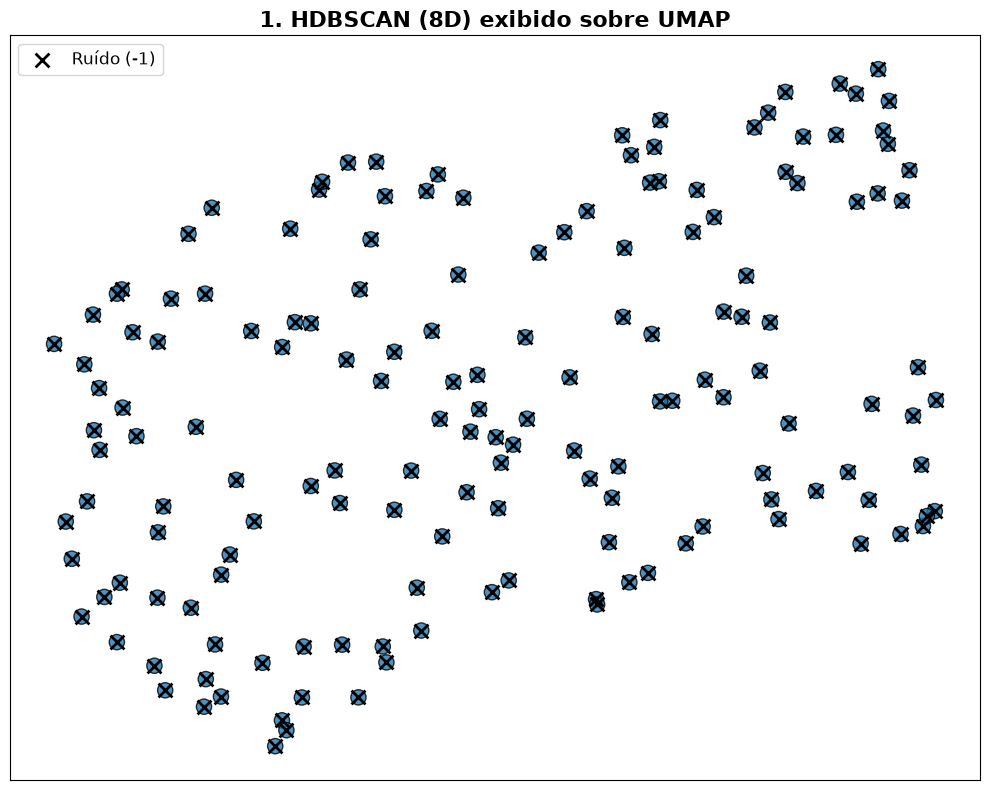

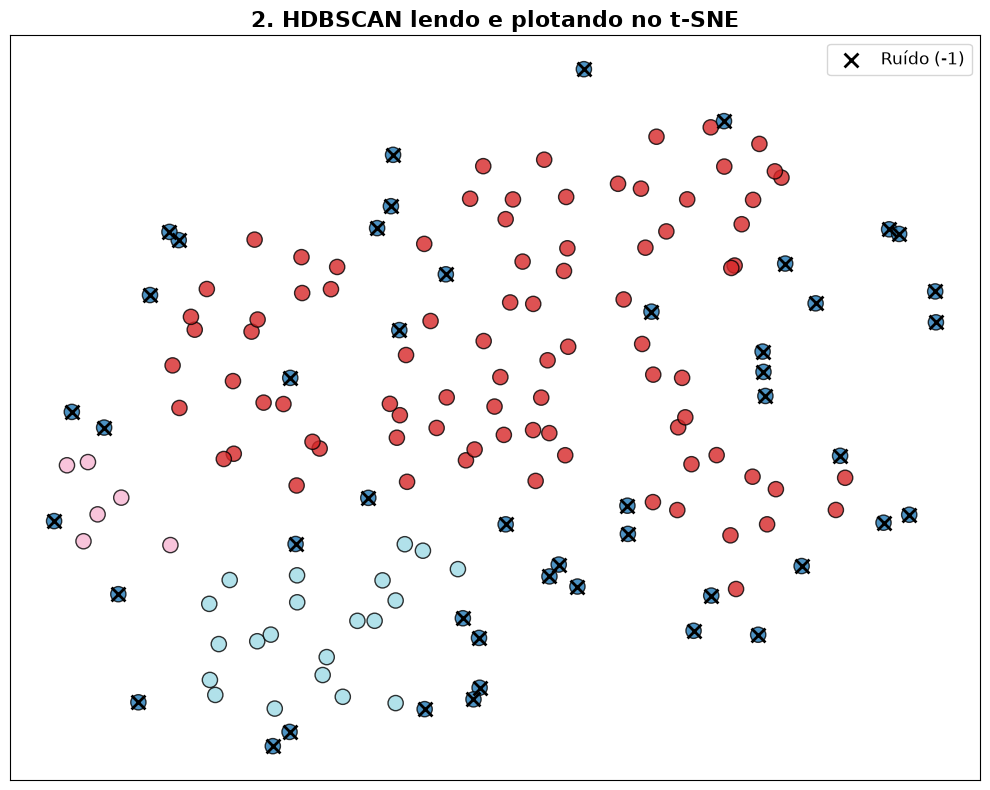

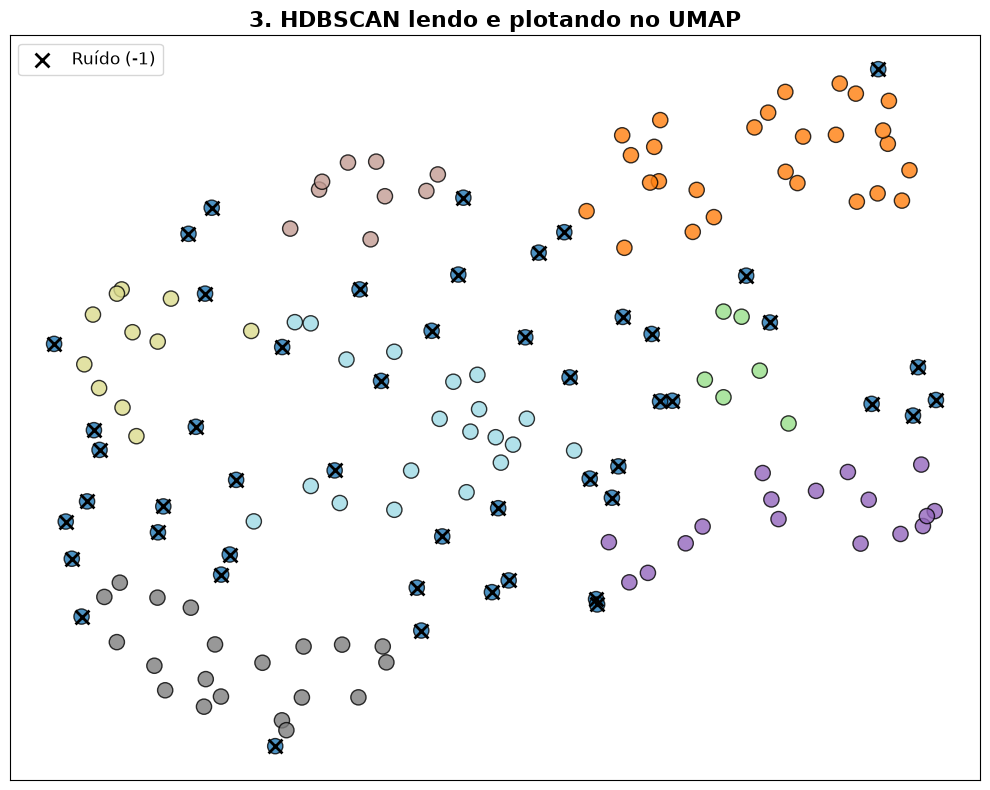


--- RESUMO DO AGRUPAMENTO ---
Grupos formados em 8D (excluindo Ruído): 0
Grupos formados em t-SNE (excluindo Ruído): 3
Grupos formados em UMAP (excluindo Ruído): 7


In [4]:
# visualização:

def plot_clusters_nativo(eixo_x, eixo_y, labels, title):
    plt.figure(figsize=(10, 8))
    
    # plotando sobre as coordenadas nativas de cada método
    scatter = plt.scatter(eixo_x, eixo_y, c=labels, cmap='tab20', 
                          s=120, alpha=0.8, edgecolors='black')
    
    # marcando o "Ruído" (-1) com X preto
    anomalias = df_season[labels == -1]
    if not anomalias.empty:
        plt.scatter(anomalias[eixo_x.name], anomalias[eixo_y.name], 
                    c='black', s=100, marker='x', label='Ruído (-1)', linewidths=2)
        plt.legend(loc='best', fontsize=12)
        
    plt.title(title, fontsize=16, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()

# o 8D não tem eixos 2D próprios, então será usado o UMAP apenas como painel de exibição
plot_clusters_nativo(df_season['UMAP1'], df_season['UMAP2'], df_season['Cluster_8D'], '1. HDBSCAN (8D) exibido sobre UMAP')

# O t-SNE e o UMAP em seus respectivos espaços topológicos
plot_clusters_nativo(df_season['TSNE1'], df_season['TSNE2'], df_season['Cluster_TSNE'], '2. HDBSCAN lendo e plotando no t-SNE')
plot_clusters_nativo(df_season['UMAP1'], df_season['UMAP2'], df_season['Cluster_UMAP'], '3. HDBSCAN lendo e plotando no UMAP')

# contagem de clusters
print("\n--- RESUMO DO AGRUPAMENTO ---")
print("Grupos formados em 8D (excluindo Ruído):", df_season['Cluster_8D'].nunique() - (1 if -1 in df_season['Cluster_8D'].values else 0))
print("Grupos formados em t-SNE (excluindo Ruído):", df_season['Cluster_TSNE'].nunique() - (1 if -1 in df_season['Cluster_TSNE'].values else 0))
print("Grupos formados em UMAP (excluindo Ruído):", df_season['Cluster_UMAP'].nunique() - (1 if -1 in df_season['Cluster_UMAP'].values else 0))

- Sobre o primeiro gráfico, as 8 dimensões:
    - Em altas dimensões, o cálculo de distância euclidiana perde a sua utilidade prática porque a diferença de distância entre o vizinho mais próximo e o vizinho mais distante tende a zero. Como o HDBSCAN constrói sua lógica inteiramente baseada em densidade (pontos apertados no mesmo espaço), ele olhou para as 8 dimensões, percebeu que todos os times estavam muito distantes uns dos outros no vazio matemático, e concluiu que nenhum padrão de grupo existia. O resultado? 100% da liga foi rotulada como Ruído (-1).
    - Esse fracasso em 8D é a prova do porquê o pipeline está estruturado da maneira correta. Ele justifica matematicamente o motivo pelo qual foram construidos o t-SNE e o UMAP: é preciso "amassar" o espaço dimensional para forçar os dados a revelarem suas densidades locais antes de tentar agrupá-los.

- Sobre o segundo gráfico, como o t-SNE tentou organizar a NFL:
    - O mega-cluster vermelho é o "limbo" da liga, nota-se como a esmagadora maioria dos times foi fundida em uma única e gigantesca massa vermelha que domina o centro, o topo e a direita do gráfico. O HDBSCAN agrupa por densidade (ele procura espaços vazios para separar os grupos). O problema? O t-SNE não criou esses espaços, ele esmagou os times medianos e ruins tão perto uns dos outros que a matemática enxergou tudo como um único bairro. Do ponto de vista analítico, um cluster gigante que engloba 70% da liga não tem utilidade estratégica.
    - Os clusters azul claro e rosa estão na região do espaço do t-SNE que representa os times excelentes, então essa divisão provavelmente representa dois estilos de jogos diferentes pra chegar ao sucesso na NFL.

- Sobre o terceiro gráfico, como o UMAP tentou organizar a NFL:
    - O Olimpo Laranja (Topo Direito): nos gráficos da redução de dimensionalidade do UMAP, o canto superior direito era onde ficavam os melhores times da história recente, pelo menos no quesito de vitórias na temporada regular, nesse contexto, o HDBSCAN confirmou matematicamente que esses times formam um cluster.
    - A Fossa Cinza (Canto Inferior Esquerdo): o polo oposto absoluto. O agrupamento isolou os times que fracassam na liga. O fracasso absoluto não é aleatório, ele tem um padrão definido e reconhecido.
    - A Estratificação da Classe Média: Este é o maior triunfo prático do modelo. Onde o t-SNE viu apenas uma enorme massa vermelha inútil, o HDBSCAN encontrou 5 ecossistemas táticos distintos (Azul-Claro, Verde-Claro, Roxo, Marrom e Amarelo). Isso indica que não existe apenas um tipo de time mediano.
    - Ainda há bastante pontos de ruído, mas aparetemente com um propósito, eles dse concentram principalmente nas "fronteiras" entre duas cores, representando times que estão no meio de uma transição de estilo de jogo, ou em algumas extremidades do espaço, representando outliers.

In [10]:
import matplotlib.colors as mcolors
from IPython.display import display, HTML

# perfilamento estatístico dos clusters (t-SNE vs UMAP)

def exibir_perfil_colorido(df, coluna_cluster, titulo):
    # agrupamento e cálculo de médias estatísticas
    perfil = df.groupby(coluna_cluster).agg(
        Qtd_Times=('team', 'count'),
        PF=('PF', 'mean'),
        PA=('PA', 'mean'),
        Pass_Yds=('Off_Pass_Yds', 'mean'),
        Rush_Yds=('Off_Rush_Yds', 'mean'),
        Carries=('Off_Carries', 'mean'),
        Turnovers_Off=('Off_Turnovers', 'mean'),
        Sacks_Def=('Def_Sacks_Produced', 'mean'),
        Turnovers_Def=('Def_Turnovers_Forced', 'mean'),
        Sucesso_SB=('Status_SB', lambda x: f"🏆 {(x == 'Campeão').sum()} | 🥈 {(x == 'Vice').sum()}")
    ).round(1)
    
    # ordenamento, pela quantidade de times no cluster
    perfil = perfil.sort_values(by='Qtd_Times', ascending=True).reset_index()
    
    # capturando a mesma escala de cores do gráfico (tab20)
    cmap = plt.get_cmap('tab20')
    norm = mcolors.Normalize(vmin=df[coluna_cluster].min(), vmax=df[coluna_cluster].max())
    
    # função para desenhar o símbolo visual via HTML
    def aplicar_cor(val):
        if val == -1:
            return '<span style="color: black; font-size: 1.2em;">✖️ Ruído (-1)</span>'
        else:
            cor_hex = mcolors.to_hex(cmap(norm(val)))
            return f'<span style="color: {cor_hex}; font-size: 1.5em;">⬤</span> Cluster {val}'

    # aplicar a renderização visual na coluna do Cluster
    perfil[coluna_cluster] = perfil[coluna_cluster].apply(aplicar_cor)
    
    # renderizar a tabela renderizando o HTML nativamente (escape=False)
    print(f"\n{'='*80}\n {titulo}\n{'='*80}")
    display(HTML(perfil.to_html(escape=False, index=False, justify='center')))

# executando a extração com a nova interface
exibir_perfil_colorido(df_season, 'Cluster_TSNE', 'PERFIL DOS CLUSTERS: t-SNE')
exibir_perfil_colorido(df_season, 'Cluster_UMAP', 'PERFIL DOS CLUSTERS: UMAP')


 PERFIL DOS CLUSTERS: t-SNE


Cluster_TSNE,Qtd_Times,PF,PA,Pass_Yds,Rush_Yds,Carries,Turnovers_Off,Sacks_Def,Turnovers_Def,Sucesso_SB
⬤ Cluster 1,6,465.3,390.3,4937.0,1764.2,414.7,22.8,42.0,24.2,🏆 2 | 🥈 1
⬤ Cluster 2,21,462.1,338.1,4326.5,2118.0,482.7,19.1,43.7,28.3,🏆 1 | 🥈 1
✖️ Ruído (-1),48,413.1,392.3,4066.1,2120.3,469.9,21.6,40.0,21.6,🏆 1 | 🥈 2
⬤ Cluster 0,85,339.6,387.2,3790.4,1903.9,446.8,21.9,40.7,19.6,🏆 1 | 🥈 1



 PERFIL DOS CLUSTERS: UMAP


Cluster_UMAP,Qtd_Times,PF,PA,Pass_Yds,Rush_Yds,Carries,Turnovers_Off,Sacks_Def,Turnovers_Def,Sucesso_SB
⬤ Cluster 1,6,414.3,406.5,4347.3,2254.7,496.3,25.3,39.0,18.5,🏆 0 | 🥈 0
⬤ Cluster 3,9,454.4,387.9,4897.8,1685.9,409.1,21.3,38.8,24.8,🏆 1 | 🥈 1
⬤ Cluster 5,11,349.1,385.7,4155.8,1605.6,408.4,22.3,46.9,21.4,🏆 0 | 🥈 0
⬤ Cluster 2,17,365.2,382.2,3453.4,2454.8,518.9,22.1,36.1,19.8,🏆 0 | 🥈 0
⬤ Cluster 4,20,292.6,453.8,3638.2,1684.0,408.2,26.0,33.0,15.3,🏆 0 | 🥈 0
⬤ Cluster 6,20,360.2,356.7,3845.0,1900.8,453.1,17.3,42.1,21.2,🏆 0 | 🥈 1
⬤ Cluster 0,27,467.9,335.0,4256.6,2211.1,492.7,18.6,43.0,28.8,🏆 1 | 🥈 3
✖️ Ruído (-1),50,377.4,385.3,3973.3,1983.5,453.1,22.1,43.5,20.5,🏆 3 | 🥈 0


- Sobre o agrupamento realizado pelo t-SNE:

    - Cluster Rosa: 
        - O DNA: um cluster pequeno de 6 times, que é ofensivamente focado no jogo aéreo, com 4.937 jardas aéreas, de longe o maior dentre os clusters nesse quesito, mas, por outro lado, tem de longe as menores jardas de corrida(1764.2) e carries(414.7). Além disso, eles cometem o maior número de turnovers (22.8), o que faz sentido sabendo de seu foco no jogo aéreo.
        - O Fator X: O que explica como eles têm 2 Campeões e 1 Vice é a defesa deles, que rouba a bola 24.2 vezes, e realiza sacks 42 vezes, sendo o segundo maior nesses dois quesitos. Eles são muito produtivos no ataque, apesar de cometerem bastante turnovers, e a defesa gera posses extras suficientes para sustentar esse tiroteio nos playoffs.

    - Cluster Azul Claro:
        - O DNA: um cluster razoável de 21 times. Eles têm o ataque terrestre muito forte, com o maior número de carries(482), e o segundo maior de jardas de corrida(2.118), e protegem a bola como ninguém (menor índice de turnovers ofensivos: 19.1).
        - O Fator X: Defensivamente, são monstros. Sofrem disparadamente o menor número de pontos (338.1) e têm o maior índice de turnovers forçados da liga (28.3). É a validação matemática das regras de associação do FP-Growth, o controle de relógio pelo ataque terrestre, junto com o ataque que não perde a bola, junto com a defesa que rouba a bola, é um caminho pro sucesso (1 Campeão e 1 Vice).

    - Cluster 0:
        - O DNA: o Cluster 0 engoliu 85 times. Eles são ruins em muitos aspectos, sendo os piores em pontos feitos, ataque aéreo, proteger a bola no ataque, e forçar turnovers defensivos. Apesar disso, ainda tiveram um campeão e um vice nesse cluster, indicando que seria necessária uma diferenciação maior pra poder identificar o que tornava esses times especiais.

    - Ruído (-1): 
        - O DNA: houveram 48 times que o algoritmo não soube classificar. Tendo como característica: segundo pior pontos feitos, pior pontos sofridos, segundo pior em ataque aéreo, terceiro pior em turnovers ofensivos, pior em sacks, e segundo pior em turnover defensivos, curiosamente, é o melhor em ataque terrestre, e segundo melhor em carries. Apesar disso tudo, tiveram 1 campeão e 2 vices dentro do ruído, indicando novamente uma necessidade de diferenciação maior.

- Sobre o agrupamento realizado pelo UMAP:

    - Cluster 0 (Laranja):
        - O DNA: o verdadeiro "Olimpo" da liga, com 27 times. Eles dominam os dois lados da bola: têm o maior número de pontos feitos (467.9) e o menor número de pontos sofridos (335.0). Apresentam um ataque terrestre fortíssimo (492.7 carries para 2211 jardas) aliado a um excelente jogo aéreo (4256 jardas) e altíssima proteção da bola (apenas 18.6 turnovers ofensivos).
        - O Fator X: a defesa é a mais letal da NFL, forçando disparadamente o maior número de turnovers (28.8) e aplicando muitos sacks (43.0). É a validação definitiva do equilíbrio perfeito entre ataque controlador de relógio e defesa de elite. Rendeu 1 Campeão e 3 Vices.

    - Cluster 3 (Marrom):
        - O DNA: o equivalente refinado do antigo cluster rosa do t-SNE. É um grupo de 9 times estritamente focado no tiroteio aéreo, com o maior número de jardas passadas (4897) e o segundo maior volume de pontos (454.4). Em contrapartida, têm um jogo terrestre pífio (apenas 409 carries e 1685 jardas).
        - O Fator X: a defesa sustenta o ataque. Eles forçam o segundo maior número de turnovers da liga (24.8), garantindo as posses extras necessárias para compensar a falta de controle de relógio. Essa fórmula agressiva garantiu 1 Campeão e 1 Vice.

    - Cluster 4 (Cinza):
        - O DNA: a "Fossa dos Perdedores". Um cluster de 20 times que representa o fundo do poço da NFL. Eles são os piores em tudo: menor número de pontos feitos (292.6), maior número de pontos sofridos (453.8), menor controle de relógio (408 carries) e o maior número de turnovers cometidos pelo ataque (26.0).
        - O Fator X: a ausência total de um. A defesa não consegue pressionar (menor índice de sacks, 33.0) nem roubar a bola (menor índice de turnovers forçados, 15.3). Como esperado, 0 sucesso (nenhum campeão ou vice).

    - Cluster 6 (Azul Claro):
        - O DNA: um grupo de 20 times altamente conservadores. Eles não brilham na pontuação (360.2) e têm jardas medianas, mas são os melhores da liga em proteger a bola, cometendo o menor número absoluto de turnovers ofensivos (apenas 17.3).
        - O Fator X: a filosofia de "não perder o próprio jogo" associada a uma defesa consistente (42.1 sacks). Foi suficiente para levar 1 time ao Super Bowl (Vice), mas falta a explosão ofensiva ou defensiva necessária para ser campeão.

    - Cluster 2 (Roxo):
        - O DNA: um cluster de 17 times completamente unidimensionais no jogo corrido. Eles têm, de longe, o maior número de corridas (518.9) e jardas terrestres (2454.8), mas o pior ataque aéreo da liga (apenas 3453 jardas).
        - O Fator X: eles controlam o relógio, mas a defesa não colabora. Forçam poucos turnovers (19.8) e têm pouquíssimos sacks (36.1). Sem defesa para apoiar o relógio, a tática falha nos playoffs. 0 sucesso.

    - Cluster 5 (Amarelo):
        - O DNA: um grupo de 11 times focado em defesa, mas com ataque manco. Eles têm o menor volume de jardas terrestres (1605) e pouquíssimas corridas, dependendo demais do passe e marcando poucos pontos (349.1).
        - O Fator X: a defesa é assustadora no Pass Rush, registrando a maior média de sacks da liga (46.9). Porém, como vimos no FP-Growth, defesa sem controle de relógio no ataque não sobrevive nos playoffs. 0 sucesso.

    - Cluster 1 (Verde Claro):
        - O DNA: um micro-cluster de 6 times caóticos. Eles conseguem produzir muitas jardas (segundo maior em jardas terrestres e bom passe), mas são extremamente displicentes com a bola (25.3 turnovers ofensivos) e sofrem muitos pontos (406.5).
        - O Fator X: a defesa não consegue compensar os erros do ataque, roubando a bola apenas 18.5 vezes. Produzir jardas sem segurar a bola resulta em 0 sucesso nos playoffs.

    - Ruído (-1):
        - O DNA: 50 times. Matematicamente, a quantidade absoluta de ruído aumentou em relação ao t-SNE (que tinha 48). Isso acontece porque o HDBSCAN foi mais rigoroso no UMAP. Para fatiar o "limbo genérico" em clusters super específicos (como o Roxo ou o Amarelo), o algoritmo exigiu um DNA estatístico muito puro. Qualquer time inconstante, híbrido, ou que estivesse no meio de uma transição tática e não se encaixasse perfeitamente no núcleo dessas 7 cores, foi ejetado para o ruído.
        - O Fator X: a diferença aqui está na qualidade do ruído em relação ao t-SNE. Enquanto o t-SNE gerou ruído por miopia de mapeamento, o UMAP usou o ruído para isolar times sem identidade misturados com Aberrações Históricas. O fato de 3 Campeões estarem aqui não é uma falha, mas uma confirmação dos resultados obtidos na Isolation Forest e no LOF. Campeões como o Chiefs de 23 (construído inteiramente em defesa) ou o Eagles de 24 (a única anomalia defensiva do ano), tiveram campanhas tão extremas e singulares que o algoritmo se recusou a forçá-los dentro de um padrão de "times comuns". Eles não formam um cluster, eles são a própria anomalia.

Buscando trazer algum insight baseando-se nessa análise, como o caminho para a vitória na NFL é cercado de variáveis caóticas e genialidades individuais, a matemática mapeia com precisão os caminhos que levam ao fracasso absoluto. Olhando para os quatro clusters do UMAP que registraram 0 Sucesso (Nenhum Campeão, Nenhum Vice), aqui está o manual baseado em evidências do que uma franquia da NFL nunca deve fazer:
    
- A Ilusão das Jardas Vazias (Baseado no Cluster 1 - Verde Claro):
    - O Erro: Produzir volume ofensivo sem proteger a bola. O Cluster 1 correu para 2254 jardas (segunda melhor marca da liga) e passou para mais de 4300 jardas. No papel, um ataque potente. Na prática, eles cometeram absurdos 25.3 turnovers ofensivos, forçando a própria defesa a entrar em campo em posições terríveis (cedendo 406.5 pontos).
    - Recomendação Prática: Nunca construir um esquema tático focado em explosão de jardas se o Quarterback/Running Back é descuidado com a bola. Jardas não ganham jogos se você entrega posses de graça para o adversário.

- A Defesa Sabotada pelo Próprio Ataque (Baseado no Cluster 5 - Amarelo):
    - O Erro: Ter uma defesa de elite no Pass Rush e um ataque que se recusa a correr. Esse cluster registrou a maior média de Sacks da NFL (46.9). No entanto, o ataque foi o pior da liga correndo com a bola (apenas 1605 jardas terrestres).
    - Recomendação Prática: Se a sua franquia gasta milhões em uma linha defensiva de elite, é obrigatório ter um ataque que controle o relógio no chão para deixar a defesa descansar no banco. Um ataque unidimensional no passe esgota a própria defesa, tornando a liderança em Sacks uma estatística menos útil nos playoffs.

- O Rolo Compressor Desdentado (Baseado no Cluster 2 - Roxo):
    - O Erro: O excesso de controle de relógio sem ameaça aérea. Este grupo correu com a bola impressionantes 518 vezes para 2454 jardas. Eles dominaram o cronômetro, mas tiveram o pior ataque aéreo da liga (apenas 3.453 jardas). Pior: a defesa não gerou posses extras (só 19.8 turnovers forçados).
    - Recomendação Prática: Correr com a bola funciona para vencer (como provou o Cluster 0 e as regras do FP-Growth), mas apenas se o adversário respeitar o seu jogo aéreo e se a sua defesa conseguir devolver a bola rapidamente. Ser estritamente previsível no chão te transforma em um alvo fácil em janeiro.

- A Passividade Defensiva Fatal (Baseado no Cluster 4 - Cinza):
    - O Erro: O colapso estrutural causado por defesas que não geram o caos. Este cluster é o fundo do poço da liga. O ataque é ruim (menos de 300 pontos e 26 turnovers), mas o prego no caixão é a defesa: menores índices de Sacks (33.0) e Turnovers Forçados (15.3).
    - Recomendação Prática: Uma franquia está matematicamente condenada se a sua defesa for passiva. Se os defensores não conseguem bater no Quarterback adversário nem roubar a bola, nenhum ajuste ofensivo será suficiente para salvar a temporada. A agressividade defensiva é o requisito mínimo para não habitar o porão da NFL.